# Extreme precipitation: Past, Present, and Future changes

In this tutorial, we explore how **extreme precipitation** has changed over time and how it might change in the future for the Molise region in Italy (NUTS2 region ITF2). This tutorial thus focuses on the **hazard** and how it changes under climate change.

```{admonition} Learning Objectives
:class: tip
By the end of this tutorial, you will understand:
- How to analyze changes in extreme precipitation using the concept of return periods
- How to interpret future projections of extreme precipitation
- Why multiple climate models are essential for assessing uncertainty
- The importance of comparing projections to historical baselines
```

```{admonition} Prerequisites
:class: note
This tutorial uses preprocessed CSV data for the Molise region in Italy (ITF2). See the [How-To Guide on Projections of Precipitation](../how-to-guides/precipitation_c3satlas.ipynb) to download and process precipitation projections from the CDS. 
```

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

# Configure plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Settings

In [2]:
# Configuration
admin_id = 'ITF2'

# Reference period for baseline statistics
baseline_start = 1976
baseline_end = 2005

# Analysis settings
rolling_window = 30  # years for rolling mean

# Paths
workdir = Path("/home/nejk/code/extreme_precip_exposure")
os.chdir(workdir)
data_dir = workdir / 'data' / admin_id / 'extreme_precip_exposure'

# Load preprocessed data
print(f"Region: {admin_id} (Molise, Italy)")
hist_file = data_dir / f'{admin_id}_precip_hist_amax_nutsmax.csv'
print(f"Historical data: {hist_file}")
proj_file = data_dir / f'{admin_id}_precip_proj_amax_nutsmax.csv'
print(f"Projection data: {proj_file}")

Region: ITF2 (Molise, Italy)
Historical data: /home/nejk/code/extreme_precip_exposure/data/ITF2/extreme_precip_exposure/ITF2_precip_hist_amax_nutsmax.csv
Projection data: /home/nejk/code/extreme_precip_exposure/data/ITF2/extreme_precip_exposure/ITF2_precip_proj_amax_nutsmax.csv


## Examining historical extreme precipitation 


### Using one climate model

We begin by examining the **historical record** of extreme precipitation using historical simulations from climate models. 

Let's load the historical data and visualize the extremes:

In [3]:
# Load historical data
hist_df = pd.read_csv(hist_file)
hist_df['year'] = pd.to_datetime(hist_df['year'], format='%Y')
hist_df = hist_df.sort_values('year')

print(f"Historical data: {hist_df['year'].min().year} to {hist_df['year'].max().year}, i.e., {hist_df['year'].max().year - hist_df['year'].min().year + 1} years")
print(f"Number of data entries: {len(hist_df)/(hist_df['year'].max().year - hist_df['year'].min().year + 1):.20f} entries per year")
hist_df.head()

# remove duplicate rows if any
hist_df = hist_df.drop_duplicates(subset=['year', 'member_id', 'rx1day'])
print(f"Number of data entries (after cleanup): {len(hist_df)/(hist_df['year'].max().year - hist_df['year'].min().year + 1):.20f} entries per year")


Historical data: 1970 to 2005, i.e., 36 years
Number of data entries: 142.00000000000000000000 entries per year
Number of data entries (after cleanup): 71.00000000000000000000 entries per year


### Using the multi-model ensemble

Now let's see how the other climate models simulate the same historical period.

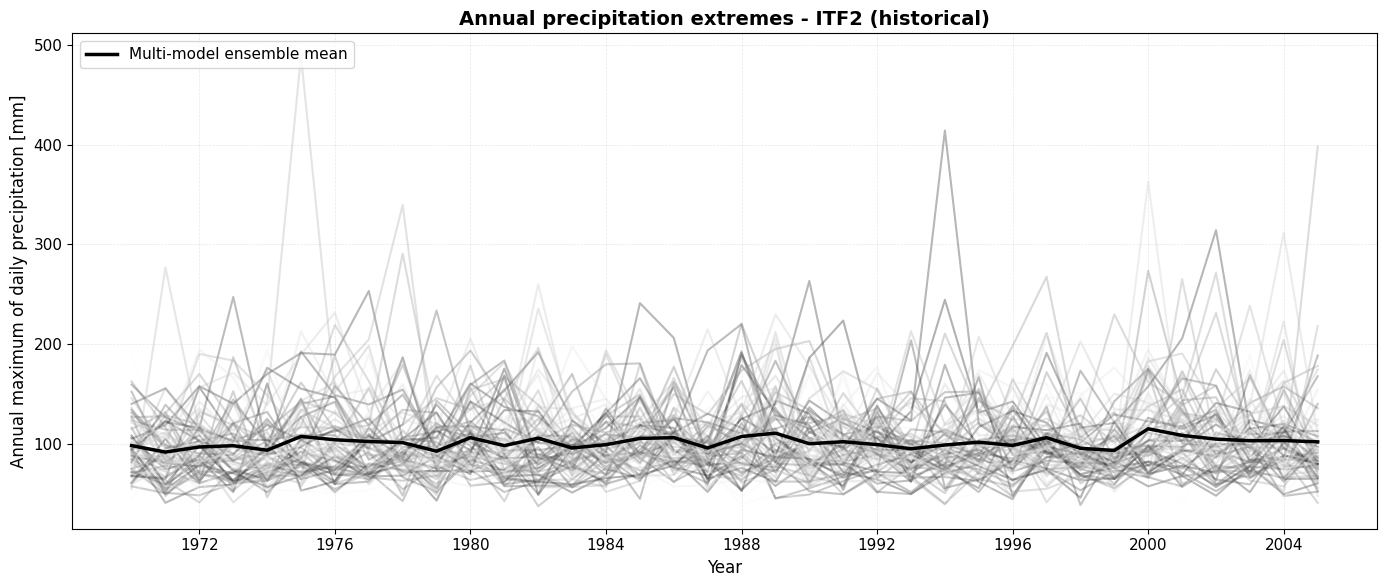

In [4]:
# plot climate model ensemble from hist_df using thin lines for each member and a thick line for the ensemble mean
ensemble_mean = hist_df.groupby('year')['rx1day'].mean()

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=hist_df, x='year', y='rx1day', hue='member', 
             palette='gray', alpha=0.3, legend=False, ax=ax)
sns.lineplot(x=ensemble_mean.index, y=ensemble_mean.values, 
             color='black', linewidth=2.5, label='Multi-model ensemble mean', ax=ax)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Annual maximum of daily precipitation [mm]', fontsize=12)
ax.set_title(f'Annual precipitation extremes - {admin_id} (historical)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Let's extract some first model statistics

In [5]:
# Print out statistics for the ensemble:
print(f"\nHistorical annual maximum of daily precipitation statistics (multi-model ensemble mean):")
print(f"  Mean: {ensemble_mean.mean():.2f} mm/year")
print(f"  Std: {ensemble_mean.std():.2f} mm/year")
print(f"  Min: {ensemble_mean.min():.2f} mm/year ({ensemble_mean.idxmin().year})")
print(f"  Max: {ensemble_mean.max():.2f} mm/year ({ensemble_mean.idxmax().year})")

# Single model statistics, for comparison
# Print out model with highest and lowest mean annual maximum of daily precipitation
model_means = hist_df.groupby('member_id')['rx1day'].mean()
print(f"\nModel with highest mean annual maximum of daily precipitation: {model_means.idxmax()} ({model_means.max():.2f} mm/year)")
print(f"Model with lowest mean annual maximum of daily precipitation: {model_means.idxmin()} ({model_means.min():.2f} mm/year)")
# Print out model and year with highest annual maximum of daily precipitation
max_row = hist_df.loc[hist_df['rx1day'].idxmax()]
print(f"Model and year with highest annual maximum of daily precipitation: {max_row['member_id']} ({max_row['year'].year}, {max_row['rx1day']:.2f} mm/year)")
# Print out model and year with lowest annual maximum of daily precipitation
min_row = hist_df.loc[hist_df['rx1day'].idxmin()]
print(f"Model and year with lowest annual maximum of daily precipitation:  {min_row['member_id']} ({min_row['year'].year}, {min_row['rx1day']:.2f} mm/year)")


Historical annual maximum of daily precipitation statistics (multi-model ensemble mean):
  Mean: 101.08 mm/year
  Std: 5.44 mm/year
  Min: 91.62 mm/year (1971)
  Max: 114.96 mm/year (2000)

Model with highest mean annual maximum of daily precipitation: CNRM-CERFACS_CNRM-CM5_r1i1p1_DMI_HIRHAM5_v2 (145.77 mm/year)
Model with lowest mean annual maximum of daily precipitation: NCC_NorESM1-M_r1i1p1_IPSL_WRF381P_v1 (66.58 mm/year)
Model and year with highest annual maximum of daily precipitation: MOHC_HadGEM2-ES_r1i1p1_UHOH_WRF361H_v1 (1975, 488.99 mm/year)
Model and year with lowest annual maximum of daily precipitation:  ICHEC_EC-EARTH_r3i1p1_CLMcom-ETH_COSMO-crCLIM-v1-1_v1 (1982, 37.30 mm/year)


## Extreme value statistics

CCCma_CanESM2_r1i1p1_CLMcom_CCLM4-8-17_v1
Error fitting GEV for member CCCma_CanESM2_r1i1p1_CLMcom_CCLM4-8-17_v1: name 'genextreme' is not defined
Data for member CCCma_CanESM2_r1i1p1_CLMcom_CCLM4-8-17_v1:
0       106.062500
213      74.269530
355      84.162110
497      51.524414
639     160.358400
710      52.837890
923      62.246094
1065    115.925780
1207     81.186520
1349     42.914062
1491    113.150390
1633     65.780270
1775     61.720703
1917     59.228516
2059     65.427734
2201     68.622070
2343     78.072266
2485    107.849610
2627     52.333984
2769    143.381840
2911    130.124020
3053     81.326170
3195     71.878910
3337     70.320310
3479     93.684570
3621     77.372070
3763     63.751953
3905     73.774414
4047     45.788086
4189    122.427734
4331     70.664060
4473     93.544920
4615     86.786130
4757    115.824220
4899     88.291990
5041     79.680664
Name: rx1day, dtype: float64
CCCma_CanESM2_r1i1p1_GERICS_REMO2015_v1
Error fitting GEV for member CCCma_CanESM

NameError: name 'genextreme' is not defined

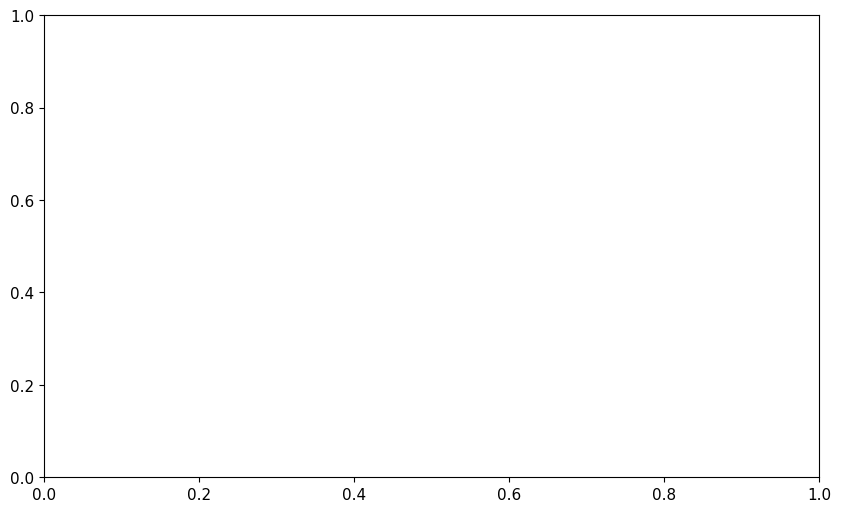

In [6]:
# Create the same return level plot but plot all models (members) as thin lines and the ensemble mean as a thick line
fig, ax = plt.subplots(figsize=(10, 6))
for member_id, group in hist_df.groupby('member_id'):
    print(member_id)
    try:
        c, loc, scale = genextreme.fit(group['rx1day'].dropna())
        return_levels = genextreme.ppf(1 - 1/return_periods, c, loc, scale)
        ax.plot(return_periods, return_levels, color='gray', alpha=0.3)
    except Exception as e:
        print(f"Error fitting GEV for member {member_id}: {e}")
        print(f"Data for member {member_id}:")
        print(group['rx1day'])
# Plot ensemble mean return level curve
ensemble_return_levels = genextreme.ppf(1 - 1/return_periods, c, loc, scale)  # Using parameters from member=0 for simplicity
ax.plot(return_periods, ensemble_return_levels, color='black', linewidth=2.5, label='Multi-model ensemble mean')
ax.set_xlabel('Return period (years)', fontsize=12)
ax.set_ylabel('Return level (mm/year)', fontsize=12)
ax.set_title(f'Return level curves for all models (members) - {admin_id} (historical)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# add vertical line at length of years in dataset used for fitting
nyears = len(hist_df_selected)
ax.axvline(nyears, color='black', linestyle='--', linewidth=0.75, label=f'Length of data used for fitting ({nyears} years)')
ax.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()